In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

df = pd.read_csv('../red_wine/winequality-red.csv', delimiter=';')


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1598 non-null   float64
 1   volatile acidity      1598 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1598 non-null   float64
 4   chlorides             1598 non-null   float64
 5   free sulfur dioxide   1598 non-null   float64
 6   total sulfur dioxide  1598 non-null   float64
 7   density               1598 non-null   float64
 8   pH                    1598 non-null   float64
 9   sulphates             1598 non-null   float64
 10  alcohol               1598 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [3]:


imputer = KNNImputer(n_neighbors=2)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
df_numerical = df[numerical_cols]
df_imputed = imputer.fit_transform(df_numerical)

df_imputed = pd.DataFrame(df_imputed, columns=numerical_cols)

# Convert the 'quality' column back to int
df_imputed['quality'] = df_imputed['quality'].round().astype(int)  # Use rounding to avoid data loss




# Assuming 'df' is your DataFrame after loading the data
X = df_imputed.drop(columns=['quality'])  # Exclude the target variable 'quality'

# Compute Z-scores
z_scores = np.abs((X - X.mean()) / X.std())

# Set a Z-score threshold (e.g., 3 standard deviations)
threshold = 3
outliers = (z_scores > threshold)

# Remove rows where any feature has an outlier
df_clean = df_imputed[~(outliers).any(axis=1)]



df_clean.to_csv("winequality-red-clean.csv", index=False)
df=df_clean
df.info()
print("Imputed data saved to 'winequality-red-clean.csv'")

<class 'pandas.core.frame.DataFrame'>
Index: 1458 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1458 non-null   float64
 1   volatile acidity      1458 non-null   float64
 2   citric acid           1458 non-null   float64
 3   residual sugar        1458 non-null   float64
 4   chlorides             1458 non-null   float64
 5   free sulfur dioxide   1458 non-null   float64
 6   total sulfur dioxide  1458 non-null   float64
 7   density               1458 non-null   float64
 8   pH                    1458 non-null   float64
 9   sulphates             1458 non-null   float64
 10  alcohol               1458 non-null   float64
 11  quality               1458 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 148.1 KB
Imputed data saved to 'winequality-red-clean.csv'


### Hypotheses to Test in Wine Quality Dataset
Based on the correlation matrix, we found that **alcohol**, **volatile acidity**, **citric acid**, and **sulfur dioxide** have a moderate relationship with **quality**. These hypotheses are made to see if these relationships are true or not.
1. **Higher Alcohol Content is Associated with Better Quality**: Based on the correlation matrix, alcohol is positively correlated with quality.
2. **Volatile Acidity Negatively Impacts Wine Quality**: Higher volatile acidity might be a negative attribute based on its negative correlation with quality.
3. **Higher Citric Acid Level Contributes to Higher Quality**: Citric acid has a moderate positive correlation, indicating it could improve taste and quality.
4. **Sulfur Dioxide Levels Affect Quality**: Wines with an optimal balance of free and total sulfur dioxide are hypothesized to have better ratings.


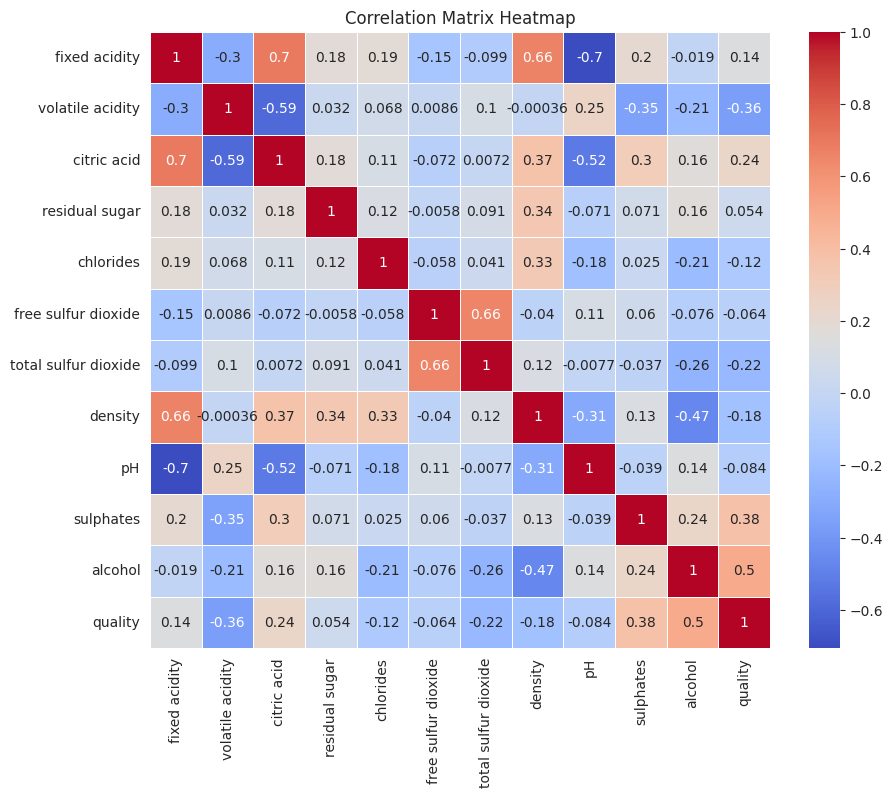

In [4]:
# Correlation Matrex
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

### Hypothesis 1: "Higher alcohol content is linked to better wine quality."

The line in the scatter plot goes up, which means wines with more alcohol usually have better quality.

We also did a **T-test** to compare alcohol content between high-quality wines (quality ≥ 7) and low-quality wines (quality ≤ 4). The **p-value** was very small (`1.3e-17`), which means the difference is real and not by chance.

This confirms that more alcohol is linked to better wine quality.


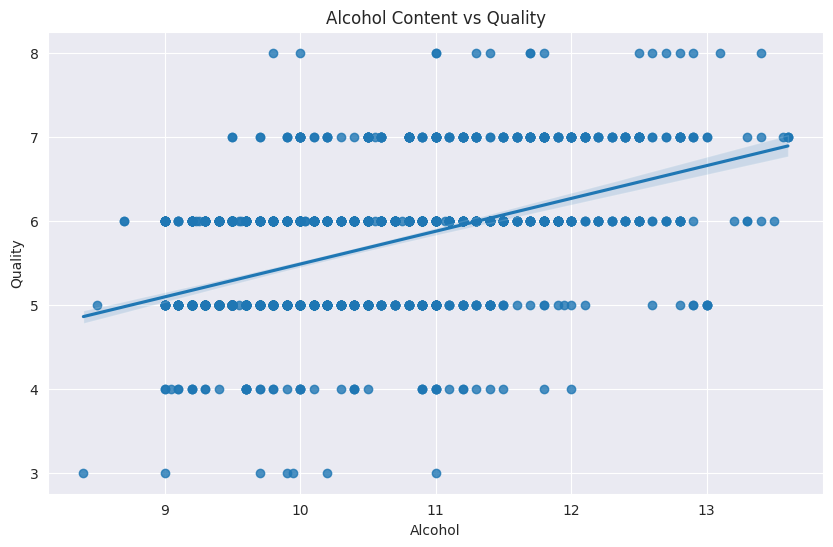

In [5]:
plt.figure(figsize=(10, 6))
sns.regplot(x='alcohol', y='quality', data=df)
plt.title('Alcohol Content vs Quality')
plt.xlabel('Alcohol')
plt.ylabel('Quality')
plt.show()

In [6]:
from scipy.stats import ttest_ind

high_quality = df[df['quality'] >= 7]['alcohol']
low_quality = df[df['quality'] <= 4]['alcohol']

# T-test to see if there's a significant difference in alcohol content
t_stat, p_value = ttest_ind(high_quality, low_quality)
print(f"T-statistic: {t_stat}, P-value: {p_value}")


T-statistic: 9.99436526313513, P-value: 4.881840418465813e-20


### Hypothesis 2: "Volatile acidity negatively impacts wine quality."

The box plot shows that when **volatile acidity** is lower, **wine quality** is usually higher. High-quality wines (7 and 8) have **less volatile acidity** compared to low-quality wines (3 and 4).

This means that **lower volatile acidity** is linked to **better wine quality**.


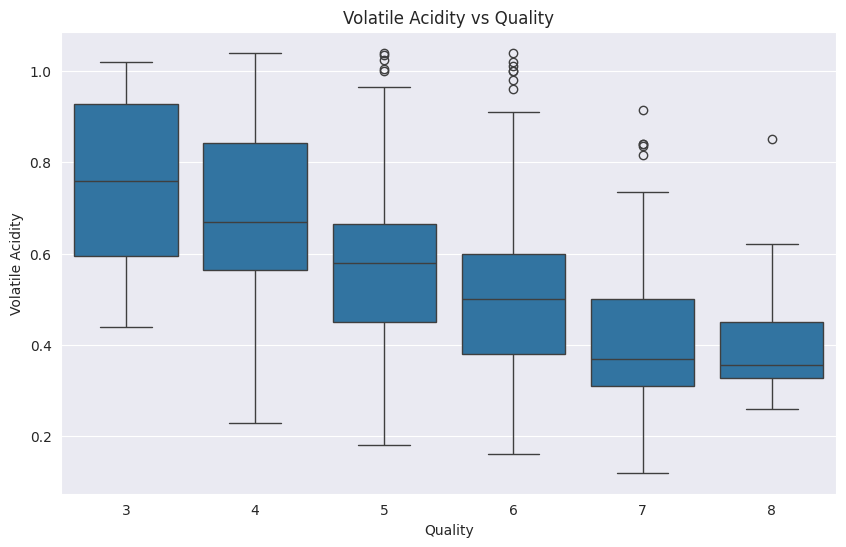

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title('Volatile Acidity vs Quality')
plt.xlabel('Quality')
plt.ylabel('Volatile Acidity')
plt.show()


### Hypothesis 3: "Higher citric acid level contributes to higher quality."

The scatter plot shows a **small positive trend**—as **citric acid** goes up, **wine quality** also gets a bit better.

The box plot shows that **high-quality wines** (7 and 8) have **more citric acid** compared to lower quality wines (3 and 4), but the difference isn't very big.

So, **more citric acid** seems to be linked to **better quality**, but the effect is **not very strong**.


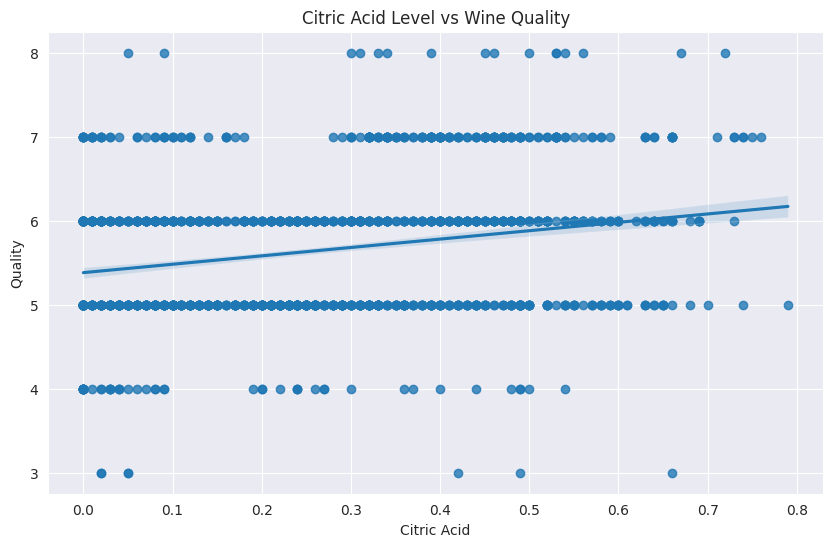

In [8]:
plt.figure(figsize=(10, 6))
sns.regplot(x='citric acid', y='quality', data=df)
plt.title('Citric Acid Level vs Wine Quality')
plt.xlabel('Citric Acid')
plt.ylabel('Quality')
plt.show()


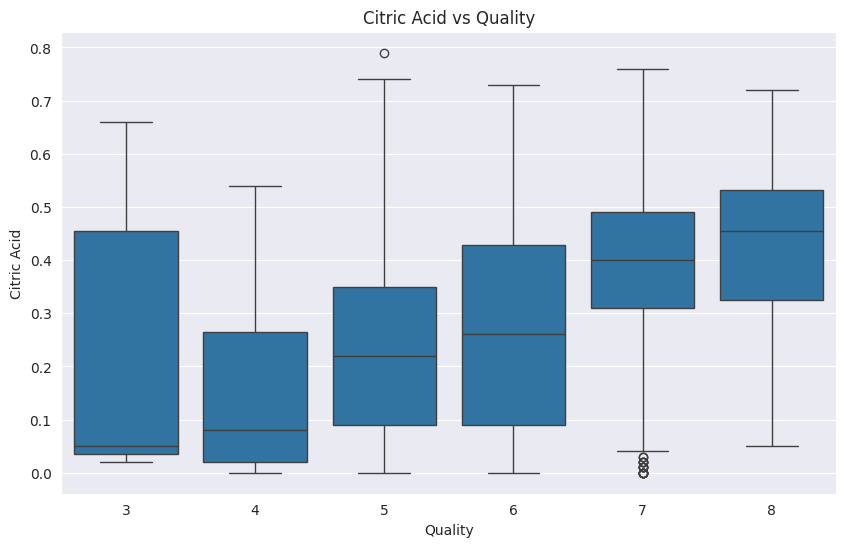

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='citric acid', data=df)
plt.title('Citric Acid vs Quality')
plt.xlabel('Quality')
plt.ylabel('Citric Acid')
plt.show()

### Hypothesis 4: "Sulfur dioxide levels affect quality."

- The **box plot for free sulfur dioxide** shows that the levels are **about the same** across different quality ratings. High-quality wines (7 and 8) have **a bit less** free sulfur dioxide, but the difference is small.

- The **box plot for total sulfur dioxide** shows a similar pattern. High-quality wines (7 and 8) have **less total sulfur dioxide** compared to lower-quality wines, but the difference is also **not big**.

- The **scatter plot of sulfur ratio** (free to total sulfur dioxide) does not show a clear trend. The values are **spread out** across all quality levels.

In short, **lower sulfur dioxide levels** might be linked to **better wine quality**, but the effect is **not very strong**. The balance of sulfur dioxide does **not seem** to clearly affect the quality.


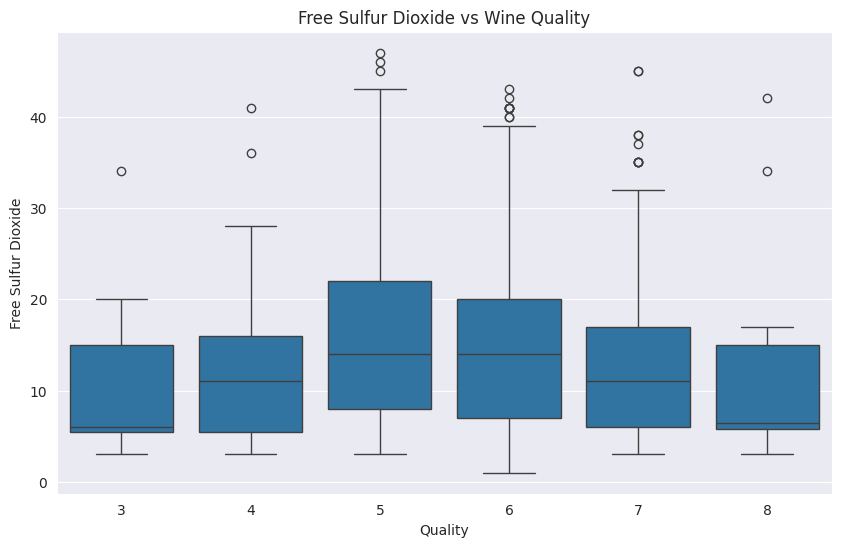

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='free sulfur dioxide', data=df)
plt.title('Free Sulfur Dioxide vs Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Free Sulfur Dioxide')
plt.show()


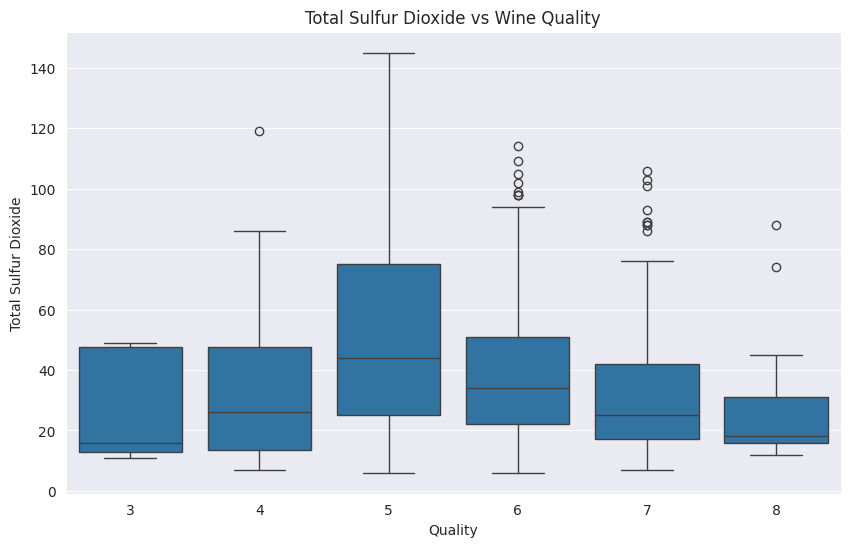

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='total sulfur dioxide', data=df)
plt.title('Total Sulfur Dioxide vs Wine Quality')
plt.xlabel('Quality')
plt.ylabel('Total Sulfur Dioxide')
plt.show()


/tmp/ipykernel_79754/3030557531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']


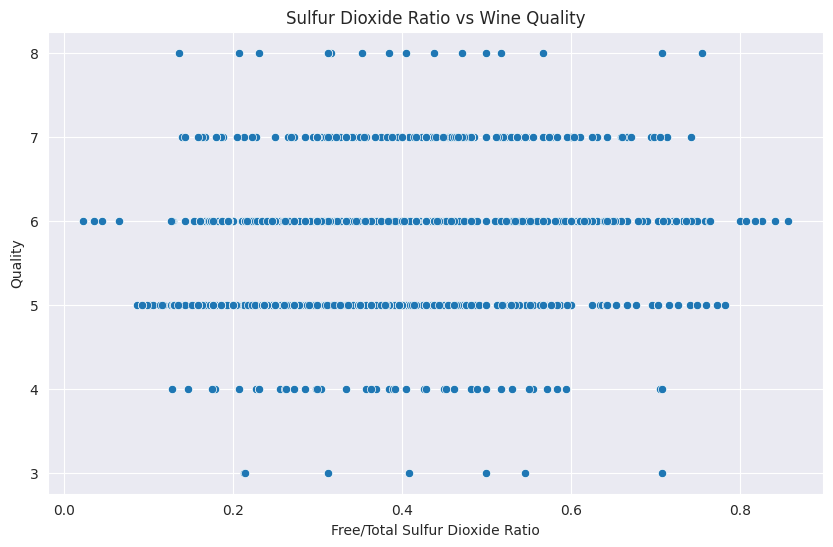

In [12]:
df['sulfur_ratio'] = df['free sulfur dioxide'] / df['total sulfur dioxide']

plt.figure(figsize=(10, 6))
sns.scatterplot(x='sulfur_ratio', y='quality', data=df)
plt.title('Sulfur Dioxide Ratio vs Wine Quality')
plt.xlabel('Free/Total Sulfur Dioxide Ratio')
plt.ylabel('Quality')
plt.show()


In [14]:
from scipy.stats import chi2

# Define features (X) and target (y)
#df.drop(columns=['sulfur_ratio'],inplace=True)  # Features: All columns except 'quality'

X = df.drop(columns=['quality'])  # Features: All columns except 'quality'
y = df['quality']           
print(y)# Target: 'quality'

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Use SelectKBest to select top 5 features based on f_regression
selector = SelectKBest(score_func=f_classif, k=5)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Train a RandomForestClassifier on the selected features
model = RandomForestClassifier(random_state=42)
model.fit(X_train_selected, y_train)

# Predict and evaluate performance using Mean Squared Error (MSE)
y_pred = model.predict(X_test_selected)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error with selected features: {mse:.4f}")

# Get the selected feature names
selected_features = X.columns[selector.get_support()]
print("\nSelected Features classification:\n", selected_features)

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1458, dtype: int64
Mean Squared Error with selected features: 0.4269

Selected Features classification:
 Index(['volatile acidity', 'citric acid', 'total sulfur dioxide', 'sulphates',
       'alcohol'],
      dtype='object')


#### To identify the best features that explain the most variance in the dataset, I analyzed the feature loadings for the top few principal components (PCs) that capture the highest explained variance. Based on the loadings for the first three principal components, which together account for approximately 59.74% of the total variance, the most significant features are **fixed acidity**, **citric acid**, **density**, **pH**, **free sulfur dioxide**, **total sulfur dioxide**, **alcohol**, and **volatile acidity**. These features were selected because they exhibit the highest loadings (positive or negative) across the first three PCs, indicating their strong contribution to the overall variance in the data. Choosing these features allows us to retain the most critical information while simplifying the model, making it suitable for further analysis or predictive modeling.

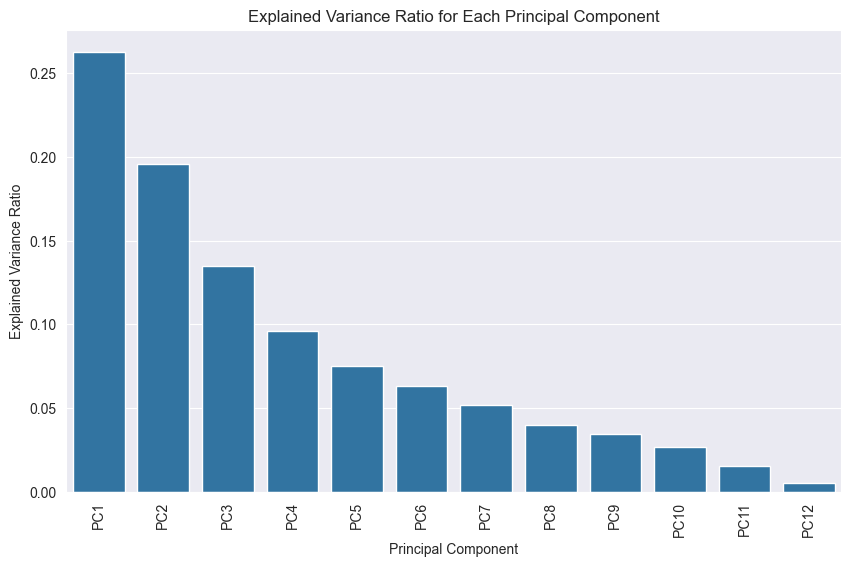


Feature Loadings onto Principal Components:
                           PC1       PC2       PC3       PC4       PC5  \
fixed acidity         0.499147 -0.129798 -0.084188 -0.071194 -0.150545   
volatile acidity     -0.318709 -0.268087 -0.188784  0.302489 -0.095816   
citric acid           0.482418  0.048173  0.116766 -0.116187 -0.122440   
residual sugar        0.162409 -0.081851  0.081890  0.766879 -0.361394   
chlorides             0.137821 -0.274894 -0.127833  0.237182  0.578742   
free sulfur dioxide  -0.102953 -0.147318  0.676959 -0.061614 -0.013927   
total sulfur dioxide -0.068635 -0.311945  0.602726 -0.026490 -0.102102   
density               0.327276 -0.411040 -0.056080  0.201185  0.102721   
pH                   -0.394951  0.143080  0.073556  0.290542  0.262989   
sulphates             0.236468  0.228899  0.261692  0.162586  0.584453   
alcohol               0.047154  0.515166  0.087325  0.279945 -0.218669   
quality               0.186098  0.447734  0.119894  0.106690  0.088

In [127]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


# separating out the features and the target variable (quality)
features = df.columns[:-1]  # adding columns except 'quality'
x = df.loc[:, features].values
y = df.loc[:, ['quality']].values  # target variable (quality)

# standardizing the features
x = StandardScaler().fit_transform(x)

# applying PCA to retain all components
pca = PCA(n_components=len(features))  # using all features
principal_components = pca.fit_transform(x)

# explained variance ratio for each principal component
explained_variance_ratio = pca.explained_variance_ratio_

# create a DataFrame to store the explained variance ratio for each component
explained_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(features))],
    'Explained Variance Ratio': explained_variance_ratio
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Principal Component', y='Explained Variance Ratio', data=explained_variance_df)

plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio for Each Principal Component')

plt.xticks(rotation=90)  # Rotate the labels for better readability
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(features))], index=features)
print("\nFeature Loadings onto Principal Components:")
print(loadings)
